# Tokenization Study

## Datasets: Loading and Cleaning

### Itihasa

In [38]:
import requests

url = "https://raw.githubusercontent.com/rahular/itihasa/main/data/dev.sn"

data = requests.get(url).text.splitlines()

In [39]:
data[:2]

['तस्यां चीरं वसानायां नाथवत्यामनाथवत्। प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥',
 'तेन तत्र प्रणादेन दुःखितः स महीपतिः। चिच्छेद जीविते श्रद्धां धर्मे यशसि चात्मनः॥ स निःश्वस्योष्णमैक्ष्वाकस्तां भार्यामिदमब्रवीत्। कैकेयि कुशचीरेण न सीता गन्तुमर्हति॥']

In [40]:
# searching for Sandhis: This just means that this dataset has sandhis and is not a disolved dataset.

matches = [line for line in data if "ऽ" in line]

print(len(matches))
print(matches[0])

1096
रामेण यदि ते पापे किंचित्कृतमशोभनम्। अपकारः क इह ते वैदेह्या दर्शितोऽधमे॥


In [41]:
import re

def clean_text(corpus:list):

    texts = []

    for sentence in corpus:
      sentence = sentence.strip()

      # normalize whitespace
      sentence = re.sub(r"\s+", " ", sentence)
      sentence = re.sub(r"\.", "", sentence)

      # separate danda symbols
      sentence = re.sub(r"॥", " ॥ ", sentence)
      sentence = re.sub(r"।", " । ", sentence)

      # separate danda symbols
      # sentence = re.sub(r"\|\|", " || ", sentence)
      # sentence = re.sub(r"\|", " | ", sentence)

      # cleanup spaces again
      sentence = re.sub(r"\s+", " ", sentence)

      """
      The following are implemented after initial encoding <==> decoding
      comparision
      """

      # cleaning nukta consonants to base consonants
      char_map = {
          "क़": "क",
          "ख़": "ख",
          "ग़": "ग",
          "ज़": "ज",
          "फ़": "फ",
          "ऩ": "न",
          "ऱ": "र"}

      for old, new in char_map.items():
        sentence = sentence.replace(old, new)


      #  cleanup symbols
      sentence = re.sub(r"\s+", " ", sentence)



      texts.append(sentence)

    return texts

In [42]:
data = clean_text(data)
data[:2]

['तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ ',
 'तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद जीविते श्रद्धां धर्मे यशसि चात्मनः ॥ स निःश्वस्योष्णमैक्ष्वाकस्तां भार्यामिदमब्रवीत् । कैकेयि कुशचीरेण न सीता गन्तुमर्हति ॥ ']

In [88]:
# Corpus Statistics:


def corpus_statistics(data):
  """
  corpus statistics
  """

# Calculate metrics for the dataset
  num_verses = len(data)

# Calculate num_lines by counting ' । ' and ' ॥ ' delimiters
  num_lines = 0
  for sentence in data:
    num_lines += sentence.count(' । ')
    num_lines += sentence.count(' ॥ ')


  total_characters = sum(len(sentence.replace(' ', '')) for sentence in data)
  total_words = sum(len(sentence.split()) for sentence in data)

  print(f"Number of verses: {num_verses}")
  print(f"Number of lines: {num_lines}")
  print(f"Total characters (excluding spaces): {total_characters}")
  print(f"Total words: {total_words}")

  # Calculate averages
  average_words_per_verse = total_words / num_verses
  average_chars_per_verse = total_characters / num_verses
  average_words_per_line = total_words / num_lines
  average_chars_per_line = total_characters / num_lines

  print(f"\n")
  print(f"Average words per verse: {average_words_per_verse:.2f}")
  print(f"Average characters per verse: {average_chars_per_verse:.2f}")
  print(f"Average words per line: {average_words_per_line:.2f}")
  print(f"Average characters per line: {average_chars_per_line:.2f}")

In [89]:
corpus_statistics(data)

Number of verses: 6148
Number of lines: 14487
Total characters (excluding spaces): 549817
Total words: 85680


Average words per verse: 13.94
Average characters per verse: 89.43
Average words per line: 5.91
Average characters per line: 37.95


## Loading the tokenizers

### GPT Tokenizers for old and new

In [45]:
# they live in the tiktoken environmemt, and here i can use the name as tokenizers using .encode:

import tiktoken
gpt_enc = tiktoken.get_encoding("cl100k_base")
o200k_enc = tiktoken.get_encoding("o200k_base")

### SentencePiece

As used by (Kumar, 2026)

In [46]:
import requests
!wget https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model

--2026-05-31 09:41:59--  https://raw.githubusercontent.com/NikhilaGadge/Sanskrit_Tokenization_Study/main/sentencepiece/spm_sa.model
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 448781 (438K) [application/octet-stream]
Saving to: ‘spm_sa.model.1’

spm_sa.model.1      100%[===================>] 438.26K  --.-KB/s    in 0.004s  

2026-05-31 09:41:59 (98.6 MB/s) - ‘spm_sa.model.1’ saved [448781/448781]



In [47]:
import sentencepiece as spm
from pathlib import Path

def load_spm(lang: str) -> spm.SentencePieceProcessor:
    sp = spm.SentencePieceProcessor()
    sp.load("spm_sa.model")
    return sp

In [48]:
sp_sa = load_spm("sa")

### SansGPT Tokenizer

In [49]:
import regex as re
import pickle
import datetime
import json
from collections import Counter
import itertools

# Similarity indicating words for Simile Aware Tokenization. These are used only for text segmentation and NOT for any rule based detection approach.

words_idicating_similarity = (r'((?i:vat| vat|samaḥ| samaḥ|samau| samau|samāḥ| samāḥ|samam| samam|samaṃ| samaṃ|'
    r'saṅkāśam| saṅkāśam|saṅkāśa| saṅkāśa|sannibhaṃ| sannibhaṃ|sannibham| sannibham|sannibha| sannibha|sannibhāḥ| sannibhāḥ|'
    r'samān| samān|samena| samena|samābhyām| samābhyām|samaiḥ| samaiḥ|samāya| samāya|'
    r'samebhyaḥ| samebhyaḥ|samāt| samāt|samād| samād|samasya| samasya|samayoḥ| samayoḥ|samānām| samānām|'
    r'sameṣu| sameṣu|samāni| samāni|samaya| samaya|samābhiḥ| samābhiḥ|samāyai| samāyai|samābhyaḥ| samābhyaḥ|'
    r'samāyaḥ| samāyaḥ|samāyām| samāyām|samāsu| samāsu|'
    r'tulyaḥ| tulyaḥ|tulyau| tulyau|tulyāḥ| tulyāḥ|tulyam| tulyam|tulyena| tulyena|tulyābhyām| tulyābhyām|'
    r'tulyaiḥ| tulyaiḥ|tulyāya| tulyāya|tulyebhyaḥ| tulyebhyaḥ|tulyo| tulyo|'
    r'tulyāt| tulyāt|tulyād| tulyād|tulyasya| tulyasya|tulyayoḥ| tulyayoḥ|tulyānām| tulyānām|'
    r'tulyeṣu| tulyeṣu|tulya| tulya|tulyāni| tulyāni|tulyayā| tulyayā|tulyābhiḥ| tulyābhiḥ|'
    r'tulyāyai| tulyāyai|tulyābhyaḥ| tulyābhyaḥ|tulyāyaḥ| tulyāyaḥ|tulyāyām| tulyāyām|tulyāsu| tulyāsu|'
    r'saṃnibhaḥ| saṃnibhaḥ|saṃnibhau| saṃnibhau|saṃnibhāḥ| saṃnibhāḥ|saṃnibham| saṃnibham|'
    r'saṃnibhena| saṃnibhena|saṃnibhābhyām| saṃnibhābhyām|saṃnibhaiḥ| saṃnibhaiḥ|'
    r'saṃnibhāt| saṃnibhāt|saṃnibhād| saṃnibhād|saṃnibhebhyaḥ| saṃnibhebhyaḥ|saṃnibhasya| saṃnibhasya|saṃnibhānām| saṃnibhānām|'
    r'saṃnibhayoḥ| saṃnibhayoḥ|saṃnibheṣu| saṃnibheṣu|saṃnibhāni| saṃnibhāni|saṃnibhām| saṃnibhām|'
    r'saṃnibhayā| saṃnibhayā|saṃnibhābhiḥ| saṃnibhābhiḥ|saṃnibhāyai| saṃnibhāyai|saṃnibhābhyaḥ| saṃnibhābhyaḥ|'
    r'saṃnibhāyāḥ| saṃnibhāyāḥ|saṃnibhāsu| saṃnibhāsu|'
    r'kalpaḥ| kalpaḥ|kalpau| kalpau|kalpāḥ| kalpāḥ|kalpam| kalpam|kalpena| kalpena|kalpābhyām| kalpābhyām|kalpaiḥ| kalpaiḥ|'
    r'kalpebhyaḥ| kalpebhyaḥ|kalpāt| kalpāt|kalpād| kalpād|kalpasya| kalpasya|kalpayoḥ| kalpayoḥ|kalpānām| kalpānām|'
    r'kalpeṣu| kalpeṣu|kalpām| kalpām|kalpayā| kalpayā|kalpābhiḥ| kalpābhiḥ|'
    r'kalpāyai| kalpāyai|kalpābhyaḥ| kalpābhyaḥ|kalpāyāḥ| kalpāyāḥ|kalpāsu| kalpāsu|kalpāni| kalpāni|'
    r'sadṛśaḥ| sadṛśaḥ|sadṛśau| sadṛśau|sadṛśāḥ| sadṛśāḥ|sadṛśam| sadṛśam|sadṛśena| sadṛśena|sadṛśābhyām| sadṛśābhyām|'
    r'sadṛśaiḥ| sadṛśaiḥ|sadṛśebhyaḥ| sadṛśebhyaḥ|sadṛśāt| sadṛśāt|sadṛśād| sadṛśād|'
    r'sadṛśasya| sadṛśasya|sadṛśayoḥ| sadṛśayoḥ|sadṛśānām| sadṛśānām|sadṛśeṣu| sadṛśeṣu|'
    r'sadṛśāni| sadṛśāni|sadṛśām| sadṛśām|sadṛśayā| sadṛśayā|'
    r'sadṛśābhiḥ| sadṛśābhiḥ|sadṛśāyai| sadṛśāyai|sadṛśābhyaḥ| sadṛśābhyaḥ|sadṛśāyāḥ| sadṛśāyāḥ|'
    r'sadṛśāsu| sadṛśāsu|sadr̥śaḥ| sadr̥śaḥ|sadr̥śau| sadr̥śau|sadr̥śāḥ| sadr̥śāḥ|'
    r'sadr̥śam| sadr̥śam|sadr̥śena| sadr̥śena|sadr̥śābhyām| sadr̥śābhyām|sadr̥śaiḥ| sadr̥śaiḥ|sadr̥śebhyaḥ| sadr̥śebhyaḥ|'
    r'sadr̥śāt| sadr̥śāt|sadr̥śād| sadr̥śād|sadr̥śasya| sadr̥śasya|sadr̥śayoḥ| sadr̥śayoḥ|sadr̥śānām| sadr̥śānām|'
    r'sadr̥śeṣu| sadr̥śeṣu|sadr̥śāni| sadr̥śāni|sadr̥śām| sadr̥śām|'
    r'sadr̥śayā| sadr̥śayā|sadr̥śābhiḥ| sadr̥śābhiḥ|sadr̥śāyai| sadr̥śāyai|sadr̥śābhyaḥ| sadr̥śābhyaḥ|'
    r'sadr̥śāyāḥ| sadr̥śāyāḥ|sadr̥śāsu| sadr̥śāsu|'
    r'samānaḥ| samānaḥ|samānau| samānau|samānāḥ| samānāḥ|samānam| samānam|samānena| samānena|'
    r'samānābhyām| samānābhyām|samānaiḥ| samānaiḥ|samānebhyaḥ| samānebhyaḥ|samānāt| samānāt|samānād| samānād|'
    r'samānasya| samānasya|samānayoḥ| samānayoḥ|samānānām| samānānām|'
    r'samāneṣu| samāneṣu|samānāni| samānāni|samānayā| samānayā|samānābhiḥ| samānābhiḥ|'
    r'samānāyai| samānāyai|samānābhyaḥ| samānābhyaḥ|samānāyāḥ| samānāyāḥ|samānāsu| samānāsu|'
    r'saṃkāśaḥ| saṃkāśaḥ|saṃkāśau| saṃkāśau|saṃkāśāḥ| saṃkāśāḥ|saṃkāśam| saṃkāśam|saṃkāśena| saṃkāśena|'
    r'saṃkāśābhyām| saṃkāśābhyām|saṃkāśaiḥ| saṃkāśaiḥ|saṃkāśebhyaḥ| saṃkāśebhyaḥ|saṃkāśāt| saṃkāśāt|saṃkāśād| saṃkāśād|'
    r'saṃkāśasya| saṃkāśasya|saṃkāśayoḥ| saṃkāśayoḥ|saṃkāśānām| saṃkāśānām|'
    r'saṃkāśeṣu| saṃkāśeṣu|saṃkāśām| saṃkāśām|saṃkāśāni| saṃkāśāni|saṃkāśayā| saṃkāśayā|saṃkāśābhiḥ| saṃkāśābhiḥ|'
    r'saṃkāśāyai| saṃkāśāyai|saṃkāśābhyaḥ| saṃkāśābhyaḥ|saṃkāśāyāḥ| saṃkāśāyāḥ|saṃkāśāsu| saṃkāśāsu|'
    r'upamaḥ| upamaḥ|upamau| upamau|upamāḥ| upamāḥ|upamam| upamam|upamena| upamena|'
    r'upamābhyām| upamābhyām|upamaiḥ| upamaiḥ|upamāya| upamāya|upamebhyaḥ| upamebhyaḥ|upamāt| upamāt|upamād| upamād|'
    r'upamasya| upamasya|upamayoḥ| upamayoḥ|upamānām| upamānām|upameṣu| upameṣu|upamām| upamām|'
    r'upamāni| upamāni|upamābhiḥ| upamābhiḥ|upamābhyaḥ| upamābhyaḥ|upamāyāḥ| upamāyāḥ|upamāsu| upamāsu|'
    r'ābhābhyām| ābhābhyām|ābhāt| ābhāt|ābhād| ābhād|ābhānām| ābhānām|ābhām| ābhām|'
    r'ābhāni| ābhāni|ābhābhiḥ| ābhābhiḥ|'
    r'ābhāyai| ābhāyai|ābhābhyaḥ| ābhābhyaḥ|ābhāyāḥ| ābhāyāḥ|ābhāsu| ābhāsu|ābhaḥ| ābhaḥ|ābhau| ābhau|'
    r'ābhāḥ| ābhāḥ|ābham| ābham|ābhena| ābhena|ābhaiḥ| ābhaiḥ|ābhebhyaḥ| ābhebhyaḥ|ābhasya| ābhasya|'
    r'ābhayoḥ| ābhayoḥ|ābheṣu| ābheṣu|ābhayā| ābhayā|'
    r'nibhaḥ| nibhaḥ|nibhau| nibhau|nibhāḥ| nibhāḥ|nibham| nibham|'
    r'nibhena| nibhena|nibhābhyām| nibhābhyām|nibhaiḥ| nibhaiḥ|'
    r'nibhebhyaḥ| nibhebhyaḥ|nibhāt| nibhāt|nibhād| nibhād|'
    r'nibhasya| nibhasya|nibhayoḥ| nibhayoḥ|nibhānām| nibhānām|'
    r'nibheṣu| nibheṣu|nibhām| nibhām|nibhayā| nibhayā|nibhābhiḥ| nibhābhiḥ|nibhāyai| nibhāyai|'
    r'nibhābhyaḥ| nibhābhyaḥ|nibhāyāḥ| nibhāyāḥ|nibhāsu| nibhāsu|'
    r'rūpaḥ| rūpaḥ|rūpau| rūpau|rūpāḥ| rūpāḥ|rūpam| rūpam|rūpān| rūpān|rūpeṇa| rūpeṇa|'
    r'rūpābhyām| rūpābhyām|rūpaiḥ| rūpaiḥ|rūpebhyaḥ| rūpebhyaḥ|'
    r'rūpāt| rūpāt|rūpād| rūpād|rūpasya| rūpasya|rūpayoḥ| rūpayoḥ|'
    r'rūpāṇām| rūpāṇām|rūpeṣu| rūpeṣu|rūpām| rūpām|rūpayā| rūpayā|'
    r'rūpābhiḥ| rūpābhiḥ|rūpāyai| rūpāyai|rūpābhyaḥ| rūpābhyaḥ|rūpāyāḥ| rūpāyāḥ|rūpāsu| rūpāsu|'
    r'pratimaḥ| pratimaḥ|pratimau| pratimau|pratimāḥ| pratimāḥ|pratimam| pratimam|pratimaṃ| pratimaṃ|'
    r'pratimena| pratimena|pratimabhyām| pratimabhyām|pratimaiḥ| pratimaiḥ|'
    r'pratimebhyaḥ| pratimebhyaḥ|pratimāt| pratimāt|'
    r'pratimād| pratimād|pratimasya| pratimasya|pratimayoḥ| pratimayoḥ|'
    r'pratimānām| pratimānām|pratimeṣu| pratimeṣu|pratimām| pratimām|'
    r'pratimayā| pratimayā|pratimābhiḥ| pratimābhiḥ|pratimāyai| pratimāyai|pratimābhyaḥ| pratimābhyaḥ|'
    r'pratimāyāḥ| pratimāyāḥ|pratimāsu| pratimāsu|'
    r'nīkāśaḥ| nīkāśaḥ|nīkāśau| nīkāśau|nīkāśāḥ| nīkāśāḥ|nīkāśam| nīkāśam'
    r'nīkāśena| nīkāśena|nīkāśābhyām| nīkāśābhyām|nīkāśaiḥ| nīkāśaiḥ|'
    r'nīkāśebhyaḥ| nīkāśebhyaḥ|nīkāśāt| nīkāśāt|nīkāśād| nīkāśād|'
    r'nīkāśasya| nīkāśasya|nīkāśayoḥ| nīkāśayoḥ|nīkāśānām| nīkāśānām'
    r'nīkāśeṣu| nīkāśeṣu|nīkāśām| nīkāśām|'
    r'nīkāśāni| nīkāśāni|nīkāśayā| nīkāśayā|nīkāśābhiḥ| nīkāśābhiḥ|nīkāśāyai| nīkāśāyai|'
    r'nīkāśābhyaḥ| nīkāśābhyaḥ|nīkāśāyāḥ| nīkāśāyāḥ|nīkāśāsu| nīkāśāsu|'
    r'pratīkāśaḥ| pratīkāśaḥ|pratīkāśau| pratīkāśau|pratīkāśāḥ| pratīkāśāḥ|'
    r'pratīkāśam| pratīkāśam|pratīkāśena| pratīkāśena|'
    r'pratīkāśābhyām| pratīkāśābhyām|pratīkāśaiḥ| pratīkāśaiḥ|'
    r'pratīkāśebhyaḥ| pratīkāśebhyaḥ|pratīkāśāt| pratīkāśāt|pratīkāśād| pratīkāśād|'
    r'pratīkāśasya| pratīkāśasya|pratīkāśayoḥ| pratīkāśayoḥ|pratīkāśānām| pratīkāśānām|'
    r'pratīkāśeṣu| pratīkāśeṣu|pratīkāśām| pratīkāśām|'
    r'pratīkāśāni| pratīkāśāni|pratīkāśayā| pratīkāśayā|pratīkāśābhiḥ| pratīkāśābhiḥ|'
    r'pratīkāśāyai| pratīkāśāyai|pratīkāśābhyaḥ| pratīkāśābhyaḥ|pratīkāśāyāḥ| pratīkāśāyāḥ|pratīkāśāsu| pratīkāśāsu|'
    r'deśyaḥ| deśyaḥ|deśyau| deśyau|deśyāḥ| deśyāḥ|deśyam| deśyam|'
    r'deśyena| deśyena|deśyāśābhyām| deśyāśābhyām|deśyaiḥ| deśyaiḥ|deśyāśāya| deśyāśāya|'
    r'deśyāśebhyaḥ| deśyāśebhyaḥ|deśyāśāt| deśyāśāt|deśyāśād| deśyāśād|'
    r'deśyasya| deśyasya|deśyayoḥ| deśyayoḥ|deśyānām| deśyānām|'
    r'deśyeṣu| deśyeṣu|deśyām| deśyām|deśyāni| deśyāni|deśyayā| deśyayā|'
    r'deśyābhiḥ| deśyābhiḥ|deśyāyai| deśyāyai|deśyābhyaḥ| deśyābhyaḥ|deśyāyāḥ| deśyāyāḥ|deśyāsu| deśyāsu|'
    r'deśīyaḥ| deśīyaḥ|deśīyau| deśīyau|deśīyāḥ| deśīyāḥ|deśīyam| deśīyam|'
    r'deśīyena| deśīyena|deśīyābhyām| deśīyābhyām|deśīyaiḥ| deśīyaiḥ|'
    r'deśīyebhyaḥ| deśīyebhyaḥ|deśīyāt| deśīyāt|deśīyād| deśīyād|deśīyasya| deśīyasya|'
    r'deśīyayoḥ| deśīyayoḥ|deśīyānām| deśīyānām|deśīyeṣu| deśīyeṣu|'
    r'deśīyām| deśīyām|deśīyāni| deśīyāni|deśīyayā| deśīyayā|'
    r'deśīyābhiḥ| deśīyābhiḥ|deśīyāyai| deśīyāyai|deśīyābhyaḥ| deśīyābhyaḥ|deśīyāyāḥ| deśīyāyāḥ|deśīyāsu| deśīyāsu|'
    r'saṃkāśo| saṃkāśo|upamo| upamo|ābho| ābho|rūpo| rūpo|vidho| vidho|pratimo| pratimo|nīkāśo| nīkāśo|pratīkāśo| pratīkāśo|'
    r'deśyo| deśyo|deśīyo| deśīyo|ivā| ivā|ivo| ivo|ive| ive|ivai| ivai|ivar| ivar|ivau| ivau|'
    r'yathā| yathā|yathe| yathe|yatho| yatho|yathar| yathar|yathai| yathai|yathau| yathau|sadṛśo| sadṛśo|sannibho| sannibho|samo| samo|kalpo| kalpo|samāno| samāno|'
    r'same| same|sama| sama|tulyān| tulyān|tulye| tulye|tulyā| tulyā|saṃnibhān| saṃnibhān|saṃnibhāya| saṃnibhāya|saṃnibhe| saṃnibhe|'
    r'saṃnibha| saṃnibha|saṃnibhā| saṃnibhā|kalpān| kalpān|kalpāya| kalpāya|kalpe| kalpe|kalpa| kalpa|kalpā| kalpā|'
    r'sadṛśān| sadṛśān|sadṛśāya| sadṛśāya|sadṛśe| sadṛśe|sadṛśa| sadṛśa|sadṛśā| sadṛśā|sadr̥śān| sadr̥śān|'
    r'sadr̥śāya| sadr̥śāya|sadr̥śe| sadr̥śe|sadr̥śa| sadr̥śa|sadr̥śā| sadr̥śā|samānān| samānān|samānāya| samānāya|'
    r'samāne| samāne|samānā| samānā|samāna| samāna|saṃkāśān| saṃkāśān|saṃkāśāya| saṃkāśāya|saṃkāśe| saṃkāśe|'
    r'saṃkāśa| saṃkāśa|saṃkāśā| saṃkāśā|upamān| upamān|upame| upame|upamā| upamā|ābhāya| ābhāya|'
    r'ābha| ābha|ābhān| ābhān|ābhā| ābhā|ābhe| ābhe|nibha| nibha|nibhān| nibhān|nibhāya| nibhāya|nibhe| nibhe|'
    r'nibhā| nibhā|rūpa| rūpa|rūpāya| rūpāya|rūpe| rūpe|rūpā| rūpā|pratimān| pratimān|pratima| pratima|'
    r'pratimāya| pratimāya|pratime| pratime|pratimā| pratimā|nīkāśa| nīkāśa|nīkāśān| nīkāśān|nīkāśāya| nīkāśāya|'
    r'nīkāśe| nīkāśe|pratīkāśān| pratīkāśān|pratīkāśāya| pratīkāśāya|pratīkāśe| pratīkāśe|'
    r'pratīkāśa| pratīkāśa|deśya| deśya|deśyān| deśyān|deśye| deśye|deśyā| deśyā|deśīya| deśīya|deśīyān| deśīyān|'
    r'deśīyāya| deśīyāya|deśīye| deśīye|nibho| nibho|iva| iva|samā| samā|upamaṃ| upamaṃ|īva| īva|prabham| prabham|upama| upama'
    r'))')


class BPETokenizer:
    def __init__(self):
        self.MergeInfo = {}
        self.Vocab = [i for i in range(256)]
        self.special_tokens = ('<bos>', '<eos>', '<sep2>', '<sep>', '<pad>')

    def special_tok(self, tok):
        if tok in self.special_tokens:
            return(self.Vocab[-(len(self.special_tokens) - self.special_tokens.index(tok))])
        else:
            raise ValueError(f"Special Token '{tok}' not found in the Tokenizer")

    def GetBigramStats(self, Text, BigramStats):
        for Bigram in zip(Text, Text[1:]):
            BigramStats[Bigram] = BigramStats.get(Bigram, 0) + 1

    def Merge(self, TextTokens, TokensToMerge, NewToken):
        Indx = 0

        while Indx < len(TextTokens) - 1:
            if TextTokens[Indx] == TokensToMerge[0] and TextTokens[Indx + 1] == TokensToMerge[1]:
                TextTokens[Indx: Indx + 2] = [NewToken]

            Indx+=1

        return TextTokens

    def GetCleanedText(self, Text, WithoutNewLine, SkipFirstChunkInLine, Replacements):

        print('Cleaning and splitting text.')

        for old, new in Replacements.items():
            Text = Text.replace(old, new)

        if WithoutNewLine and SkipFirstChunkInLine:
            CleanedText = ' '.join([line[line.find(" ") + 1:] for line in Text.splitlines()])
        elif WithoutNewLine and (not SkipFirstChunkInLine):
            CleanedText = ' '.join([line for line in Text.splitlines()])
        elif (not WithoutNewLine) and SkipFirstChunkInLine:
            CleanedText = '\n'.join([line[line.find(" ") + 1:] for line in Text.splitlines()])
        elif (not WithoutNewLine) and (not SkipFirstChunkInLine):
            CleanedText = '\n'.join([line for line in Text.splitlines()])

        SPLIT_PATTERN = re.compile(r'[^\r\n\p{L}\p{N}]?+\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]++[\r\n]*|\s*[\r\n]|\s+(?!\S)|\s+')

        splits = re.compile(words_idicating_similarity).split(CleanedText)

        SplitText = re.findall(SPLIT_PATTERN, CleanedText)
        SplitText = [match for split in splits for match in SPLIT_PATTERN.findall(split)]

        return SplitText

    def TrainVocab(self, FilePath, VocabSize, PrintStat, PrintStatsEvery_Token, WithoutNewLine, SkipFirstChunkInLine, Replacements, RemoveSpecialTok):
        """
        This function is implemented in such a way that
        it builds upon the existing vocabulary and does
        not start the training from tha scratch.
        This is implemented in such a way so that this
        function can be called multiple times to train
        a larger vocabulary size as needed by requirements
        in further control flow.
        """

        if RemoveSpecialTok:
            print('Removing Special Tokens from the Vocabulary End')
            if len(self.Vocab) > 256:
                self.Vocab = self.Vocab[:-len(self.special_tokens)]

        Text = open(FilePath, "r", encoding="utf-8").read()
        return self.TrainVocab_fromText(Text, VocabSize, PrintStat, PrintStatsEvery_Token, WithoutNewLine, SkipFirstChunkInLine, Replacements)

    def count_bigrams(self, segment):
        return Counter(zip(segment, segment[1:]))

    def TrainVocab_fromText(self, Text, VocabSize, PrintStat, PrintStatsEvery_Token, WithoutNewLine, SkipFirstChunkInLine, Replacements):

        TextTokens = self.EncodeFromText(Text, WithoutNewLine, SkipFirstChunkInLine, Replacements)

        Token = 0
        if(PrintStat):
            print(f"Vocab Training Started:\nTokens Trained:")

        while(len(self.Vocab) < (VocabSize - len(self.special_tokens))):

            Stats = Counter(itertools.chain.from_iterable(zip(seg, seg[1:]) for seg in TextTokens))

            Bigram = max(Stats, key = lambda item: Stats.get(item))
            NewToken = self.Vocab[-1] + 1
            self.MergeInfo[Bigram] = NewToken
            self.Vocab.append(NewToken)

            TextTokens = [self.Merge(seg, Bigram, NewToken) for seg in TextTokens]

            if PrintStat and (Token % PrintStatsEvery_Token == 0):
                print(len(self.Vocab), end = " - Repetitions of Bigram: ")
                print(Stats[Bigram])

            Token += 1

            if len(self.Vocab) % 1000 == 0:
                self.save('./Tokenizer/', 'Final-Corpus-Tokenizer-Merge-Info-NL-' + str(len(self.Vocab)) + '-', 'Final-Corpus-Tokenizer-Vocab-NL-' + str(len(self.Vocab)) + '-', Save_SpecialTok = False)

                self.PrintTokenizedText(TextTokens, SaveFilePath = './Tokenizer/Tokenized-Final-Corpus-' + str(len(self.Vocab)) + '.json')

        return TextTokens, self.Vocab

    def Encode(self, FilePath, WithoutNewLine, SkipFirstChunkInLine, Replacements):
        Text = open(FilePath, "r", encoding="utf-8").read()

        return self.EncodeFromText(Text, WithoutNewLine, SkipFirstChunkInLine, Replacements)

    def DecodeVocab(self, SaveFilePath = None):

        DecodedBytes = {}

        for i in range(256):
            DecodedBytes[i] = bytes([i])

        for (m0, m1), mgd in self.MergeInfo.items():
            DecodedBytes[mgd] = DecodedBytes[m0] + DecodedBytes[m1]

        TokenizedText = [DecodedBytes[tok].decode("utf-8", errors="replace") for tok in self.Vocab[:-len(self.special_tokens)]]

        if SaveFilePath != None:
            with open(SaveFilePath, 'w', encoding='utf-8') as file:
                json.dump(TokenizedText, file, ensure_ascii=False, indent=4)

                print(f"Vocab saved to: {SaveFilePath}")

    def EncodeFromText(self, Text, WithoutNewLine, SkipFirstChunkInLine, Replacements):

        Text = self.GetCleanedText(Text, WithoutNewLine, SkipFirstChunkInLine, Replacements)

        Encoded = []

        if self.MergeInfo == {}:
            for seg in Text:
                Tokens = list(seg.encode("utf-8"))
                Encoded.append(Tokens)
                print('Vocab is Empty!!')
        else:
            print(f'Encoding from Vocab - (Size: {len(self.Vocab)})')
            for seg in Text:
                Tokens = list(seg.encode("utf-8"))

                while len(Tokens) >= 2:
                    Stats = {}
                    self.GetBigramStats(Tokens, Stats)
                    Bigram = min(Stats, key = lambda p: self.MergeInfo.get(p, float("inf")))

                    if Bigram not in self.MergeInfo:
                        break

                    NewToken = self.MergeInfo[Bigram]
                    Tokens = self.Merge(Tokens, Bigram, NewToken)

                Encoded.append(Tokens)

        return Encoded

    def Decode(self, Tokens):

        DecodedBytes = {}

        for i in range(256):
            DecodedBytes[i] = bytes([i])

        for (m0, m1), mgd in self.MergeInfo.items():
            DecodedBytes[mgd] = DecodedBytes[m0] + DecodedBytes[m1]

        # These two approaches need to be switch according to the form in which Tokens is passed. Better logic can be implemented here and is a part of the To-Do list of the project.
        Bytes = [b"".join(DecodedBytes[idx] for idx in Tokens)]
        # Bytes = [b"".join(DecodedBytes[idx] for idx in seg) for seg in Tokens]

        return "".join(Chunk.decode("utf-8", errors="replace") for Chunk in Bytes)

    def PrintTokenizedText(self, Tokens, SaveFilePath = None):

        DecodedBytes = {}

        for i in range(256):
            DecodedBytes[i] = bytes([i])

        for (m0, m1), mgd in self.MergeInfo.items():
            DecodedBytes[mgd] = DecodedBytes[m0] + DecodedBytes[m1]

        TokenizedText = [[DecodedBytes[idx].decode("utf-8", errors="replace") for idx in seg] for seg in Tokens]

        if SaveFilePath != None:
            with open(SaveFilePath, 'w', encoding='utf-8') as file:
                json.dump(TokenizedText, file, ensure_ascii=False, indent=4)

                print(f"Tokenized text saved to: {SaveFilePath}")

        # print(TokenizedText)

    def save(self, path, MergeInfo_Name, Vocab_Name, Save_SpecialTok):

        if Save_SpecialTok:
            for i in range(len(self.special_tokens)):
                self.Vocab.append(len(self.Vocab))

        if(path[-1] != '/'): path += '/'

        date_time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S").replace(':', '-')

        with open(path + MergeInfo_Name + date_time + '.pkl', 'wb') as file:
            pickle.dump(self.MergeInfo, file)

        with open(path + Vocab_Name + date_time + '.pkl', 'wb') as file:
            pickle.dump(self.Vocab, file)

        print("Contents saved successfully.")

    def load(self, path, MergeInfo_Name, Vocab_Name):

        if(path[-1] != '/'): path += '/'

        with open(path + MergeInfo_Name + '.pkl', 'rb') as file:
            self.MergeInfo = pickle.load(file)

        with open(path + Vocab_Name + '.pkl', 'rb') as file:
            self.Vocab = pickle.load(file)

        print('Loaded Vocabulary!')
        print(f'Vocab Size: {len(self.Vocab)}')
        print(f'MergeInfo Size: {len(self.MergeInfo)}')

### Sutra

In [50]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer

login(userdata.get("HF_TOKEN"))
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")

## Evaluation

### HF tokenizers

In [36]:
from transformers import AutoTokenizer

claude = AutoTokenizer.from_pretrained("Xenova/claude-tokenizer")
tiny = AutoTokenizer.from_pretrained("openaccess-ai-collective/tiny-mistral")
sutra = AutoTokenizer.from_pretrained("TWO/sutra-mlt256-v2")
qwen_sanskrit_model = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-Qwen2.5-7B-base")
qwen_sanskrit_tokenizer = AutoTokenizer.from_pretrained("diabolic6045/Sanskrit-English-qwen2-tokenizer")
mt5 = AutoTokenizer.from_pretrained("google/mt5-small")
mbart = AutoTokenizer.from_pretrained("facebook/mbart-large-50")
airavata = AutoTokenizer.from_pretrained("ai4bharat/Airavata") # needs login
llama = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct") # needs login # access granted
aya = AutoTokenizer.from_pretrained("CohereLabs/aya-expanse-8b") # needs login
gemma = AutoTokenizer.from_pretrained("google/gemma-1.1-2b-it") # needs login

tokenizer_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.77M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/626 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

### Metadata

In [37]:
import pandas as pd


def tokenizer_metadata_table(tokenizers_dict):

    rows = []

    for label, tok in tokenizers_dict.items():

        row = {

            "label": label,

            "class": type(tok).__name__,
        }

        # -----------------------------
        # vocab size
        # -----------------------------
        if hasattr(tok, "vocab_size"):

            row["vocab_size"] = tok.vocab_size

        elif hasattr(tok, "n_vocab"):

            row["vocab_size"] = tok.n_vocab

        else:

            row["vocab_size"] = "not available"

        # -----------------------------
        # model path / tokenizer name
        # -----------------------------
        if hasattr(tok, "name_or_path"):

            row["model_path"] = tok.name_or_path

        elif hasattr(tok, "name"):

            row["model_path"] = tok.name

        else:

            row["model_path"] = "not available"


        # -----------------------------
        # backend tokenizer model
        # -----------------------------
        try:

            row["backend_model"] = str(tok.backend_tokenizer.model)

        except:

            try:

                row["backend_model"] = tok.__class__.__name__

            except:

                row["backend_model"] = "not available"

        # -----------------------------
        # special tokens
        # -----------------------------
        try:

            row["special_tokens"] = tok.special_tokens_map

        except:

            try:

                row["special_tokens"] = tok._special_tokens

            except:

                row["special_tokens"] = "not available"

        rows.append(row)

    df = pd.DataFrame(rows)

    return df

In [52]:
tokenizers = {

    "claude": claude,
    "tiny_mistral": tiny,
    "sutra": sutra,
    "qwen_sanskrit_model": qwen_sanskrit_model,
    "qwen_sanskrit_tokenizer": qwen_sanskrit_tokenizer,
    "mt5": mt5,
    "mbart": mbart,
    "airavata" : airavata, # needs login
    "llama": llama, # needs login # access granted
    "aya": aya, # needs login
    "gemma": gemma, # needs login
    "cl100k_base": gpt_enc,
    "o200k_base": o200k_enc
}

meta_df = tokenizer_metadata_table(tokenizers)

meta_df

,label,class,vocab_size,model_path,backend_model,special_tokens
0,claude,GPT2Tokenizer,65000,Xenova/claude-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<EOT>', 'eos_token': '<EOT>', '..."
1,tiny_mistral,TokenizersBackend,32000,openaccess-ai-collective/tiny-mistral,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
2,sutra,TokenizersBackend,256001,TWO/sutra-mlt256-v2,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
3,qwen_sanskrit_model,Qwen2Tokenizer,151643,diabolic6045/Sanskrit-Qwen2.5-7B-base,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|endoftext|>', 'pad_token': '<..."
4,qwen_sanskrit_tokenizer,TokenizersBackend,120000,diabolic6045/Sanskrit-English-qwen2-tokenizer,"BPE(dropout=None, unk_token=None, continuing_s...","{'eos_token': '<|im_end|>', 'unk_token': '<unk..."
5,mt5,T5Tokenizer,250100,google/mt5-small,"Unigram(unk_id=2, vocab=[(""<pad>"", 0), (""</s>""...","{'eos_token': '</s>', 'unk_token': '<unk>', 'p..."
6,mbart,MBart50Tokenizer,250054,facebook/mbart-large-50,"Unigram(unk_id=3, vocab=[(""<s>"", 0), (""<pad>"",...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
7,airavata,TokenizersBackend,48064,ai4bharat/Airavata,"BPE(dropout=None, unk_token=""<unk>"", continuin...","{'bos_token': '<s>', 'eos_token': '</s>', 'unk..."
8,llama,TokenizersBackend,128000,meta-llama/Llama-3.1-8B-Instruct,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<|begin_of_text|>', 'eos_token'..."
9,aya,CohereTokenizer,255000,CohereLabs/aya-expanse-8b,"BPE(dropout=None, unk_token=None, continuing_s...","{'bos_token': '<BOS_TOKEN>', 'eos_token': '<|E..."


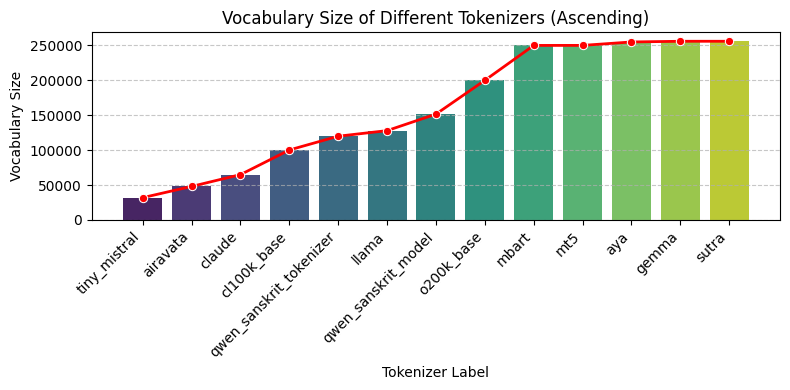

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort meta_df by vocab_size in ascending order
sorted_meta_df = meta_df.sort_values(by='vocab_size', ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(x='label', y='vocab_size', data=sorted_meta_df, palette='viridis', hue='label', legend=False, order=sorted_meta_df['label'])
# Add a rising red line
sns.lineplot(x='label', y='vocab_size', data=sorted_meta_df, color='red', marker='o', linewidth=2, sort=False)
plt.title('Vocabulary Size of Different Tokenizers (Ascending)')
plt.xlabel('Tokenizer Label')
plt.ylabel('Vocabulary Size')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
# SansGPT tokenizer - complicated

bpetokenizer = BPETokenizer()

tokens, vocab = bpetokenizer.TrainVocab_fromText(
    Text=data,
    VocabSize=300,
    PrintStat=True,
    PrintStatsEvery_Token=10,
    WithoutNewLine=True,
    SkipFirstChunkInLine=False,
    Replacements={}
)

Cleaning and splitting text.


AttributeError: 'list' object has no attribute 'splitlines'

In [20]:
# SansGPT BPE Tokenizer:
# as implemented in paper

Tokenizer = BPETokenizer()
Tokenizer.load(vocab_path, merge_info_name, vocab_name)

# This is done to remove the special tokens from the vocab when tokenizing for pre-training.
if remove_last_n_merge_info:
  Tokenizer.MergeInfo = remove_last_n_elements_from_dict(Tokenizer.MergeInfo, len(Tokenizer.special_tokens))

print("Tokenizing Files")

Tokens = Tokenizer.Encode(sans_file_path, WithoutNewLine = without_new_line, SkipFirstChunkInLine = skip_first_chunk_in_line, Replacements = replacements)
Tokens = [t for sub_t in Tokens for t in sub_t]


NameError: name 'vocab_path' is not defined

In [54]:
import pandas as pd
import numpy as np
from google.colab import files

def tokenize(data: list, tokenizer, tokenizer_label):
    """
    Tokenizes each sentence individually.
    Returns a DataFrame — one row per sentence.
    """

    records = []

    for sentence in data:

        if not sentence.strip():
            continue

        tokens = tokenizer.encode(sentence)

        try:
          token_strings = tokenizer.tokenize(sentence)
        except:
          token_strings = [tokenizer.decode([t]) for t in tokens] # Converts each token ID back into readable token text/subword like 15266 --> Hello

        words = sentence.split()

        num_tokens = len(tokens) # Number of total generated tokens per sentence
        num_words = len(words) # number of total words in sentence
        num_chars = len(sentence.replace(" ", "")) # total number of charachters --> in english one letter - one charachter

        try:
            decoded = tokenizer.decode(tokens, skip_special_tokens=True)
        except:
            decoded = tokenizer.decode(tokens)

        records.append({

            "sentence": sentence,
            "decoded_sentence": decoded,
            "tokens": token_strings,
            "similarity": sentence == decoded,
            "num_words": num_words,
            "num_tokens": num_tokens,
            # "unique_tokens_count": len(set(tokens)), # more useful at corpus level
            "token_ids": tokens,
            "num_chars": num_chars,
            "fertility": num_tokens / num_words if num_words > 0 else None, # Average tokens per word
            "tokens_per_char": num_tokens / num_chars if num_chars > 0 else None, # how many tokens needed to represent one charachter
            "chars_per_token": num_chars / num_tokens if num_tokens > 0 else None, # aka Compression Ratio , how many chars packed into one token?
            "tokenizer": tokenizer_label
        })

    df = pd.DataFrame(records)

    #filename = f"tokenizer_analysis_{tokenizer_label}.xlsx"

    #df.to_excel(filename, index=False)

    #files.download(filename)

    return df

## Tokenizer wise results:

In [55]:
tokenize(data, qwen_sanskrit_tokenizer,"qwen_sanskrit_tokenizer").head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁तस्यां, ▁ची, रं, ▁वस, ान, ायां, ▁नाथ, वत्या,...",True,13,21,"[6347, 23964, 645, 2778, 245, 1616, 6661, 1747...",73,1.615385,0.287671,3.476190,qwen_sanskrit_tokenizer
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[▁तेन, ▁तत्र, ▁प्रण, ादेन, ▁दुःखितः, ▁स, ▁महीप...",True,24,36,"[1414, 769, 2187, 74435, 21910, 223, 10427, 22...",146,1.500000,0.246575,4.055556,qwen_sanskrit_tokenizer


In [56]:
verse = data[0]

In [31]:
print(len(qwen_sanskrit_tokenizer.encode(verse)))
print(len(qwen_sanskrit_model.encode(verse)))
print(len(o200k_enc.encode(verse)))

21
83
40


In [57]:
print(type(qwen_sanskrit_model))
print(type(qwen_sanskrit_tokenizer))
print("qwen_sanskrit_model:", qwen_sanskrit_model.name_or_path)
print("qwen_sanskrit_tokenizer:", qwen_sanskrit_tokenizer.name_or_path)
print("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer.tokenize(verse))
print("qwen_sanskrit_model", qwen_sanskrit_model.tokenize(verse))

<class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>
<class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
qwen_sanskrit_model: diabolic6045/Sanskrit-Qwen2.5-7B-base
qwen_sanskrit_tokenizer: diabolic6045/Sanskrit-English-qwen2-tokenizer
qwen_sanskrit_tokenizer ['▁तस्यां', '▁ची', 'रं', '▁वस', 'ान', 'ायां', '▁नाथ', 'वत्या', 'म', 'नाथवत्', '▁।', '▁प्रचु', 'क्रोश', '▁जनः', '▁सर्वो', '▁धिक्', '▁त्वां', '▁दशरथं', '▁त्विति', '▁॥', '▁']
qwen_sanskrit_model ['à¤¤', 'à¤¸', 'à¥įà¤', '¯', 'à¤¾à¤', 'Ĥ', 'Ġà¤', 'ļ', 'à¥Ģ', 'à¤°', 'à¤Ĥ', 'Ġà¤', 'µ', 'à¤¸', 'à¤¾à¤', '¨', 'à¤¾à¤', '¯', 'à¤¾à¤', 'Ĥ', 'Ġà¤', '¨', 'à¤¾à¤', '¥', 'à¤µ', 'à¤¤', 'à¥įà¤', '¯', 'à¤¾à¤', '®', 'à¤¨', 'à¤¾à¤', '¥', 'à¤µ', 'à¤¤', 'à¥į', 'Ġ', '।', 'Ġà¤ª', 'à¥įà¤°', 'à¤ļ', 'à¥ģ', 'à¤ķ', 'à¥įà¤°', 'à¥ĭ', 'à¤¶', 'Ġà¤', 'ľ', 'à¤¨', 'à¤', 'ĥ', 'Ġà¤¸', 'à¤°', 'à¥įà¤', 'µ', 'à¥ĭ', 'Ġà¤', '§', 'à¤¿à¤', 'ķ', 'à¥į', 'Ġà¤', '¤', 'à¥įà¤', 'µ', 'à¤¾à¤', 'Ĥ', 'Ġà¤', '¦', 'à¤¶', 'à¤°', 'à¤¥', 'à¤Ĥ', 'Ġà¤', '¤', 'à

In [58]:
print(qwen_sanskrit_model.encode("राम"))
print(qwen_sanskrit_model.tokenize("राम"))

print(qwen_sanskrit_tokenizer.encode("राम"))
print(qwen_sanskrit_tokenizer.tokenize("राम"))

[44179, 31411, 106]
['à¤°', 'à¤¾à¤', '®']
[2050]
['▁राम']


In [59]:
tokenize(data, claude,"claude").head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤, ¯, à¤¾, à¤Ĥ, Ġà¤, ļ, à¥Ģ, ...",True,13,103,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.923077,1.410959,0.708738,claude
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[à¤¤, à¥ĩ, à¤¨, Ġà¤, ¤, à¤¤, à¥į, à¤°, Ġà¤, ª,...",True,24,203,"[45793, 29050, 37134, 13348, 102, 45793, 38639...",146,8.458333,1.390411,0.719212,claude


In [60]:
tokenize(data, gpt_enc,"cl100k_base").head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[त, स, ्�, �, ा�, �, �, �, ी, र, ं, �, �, स,...",True,13,91,"[80338, 79468, 31584, 107, 32511, 224, 15272, ...",73,7.000000,1.246575,0.802198,cl100k_base
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[त, े�, �, �, �, त, ्र, प, ्र, �, �, ा�, �, ...",True,24,179,"[80338, 55884, 101, 15272, 97, 80338, 86133, 8...",146,7.458333,1.226027,0.815642,cl100k_base


In [61]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),


]

for tok, name in tokenizers:
  temp_df = tokenize(data, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

Token indices sequence length is longer than the specified maximum sequence length for this model (2023 > 1024). Running this sequence through the model will result in indexing errors


In [62]:
# uncomment to download a file

"""

filename = f"tokenizer_analysis.xlsx"

df.to_excel(filename, index=False)

files.download(filename)

"""

'\n\nfilename = f"tokenizer_analysis.xlsx"\n\ndf.to_excel(filename, index=False)\n\nfiles.download(filename)\n\n'

In [63]:
df['tokenizer'].unique()

array(['claude', 'tiny', 'sutra', 'qwen_sanskrit_model',
       'qwen_sanskrit_tokenizer', 'mt5', 'mbart', 'airavata', 'llama',
       'aya', 'gemma', 'cl100k_base', 'o200k_base'], dtype=object)

In [64]:
df.head(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤, ¯, à¤¾, à¤Ĥ, Ġà¤, ļ, à¥Ģ, ...",True,13,103,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.923077,1.410959,0.708738,claude
1,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,तेन तत्र प्रणादेन दुःखितः स महीपतिः । चिच्छेद ...,"[à¤¤, à¥ĩ, à¤¨, Ġà¤, ¤, à¤¤, à¥į, à¤°, Ġà¤, ª,...",True,24,203,"[45793, 29050, 37134, 13348, 102, 45793, 38639...",146,8.458333,1.390411,0.719212,claude


In [65]:
df.tail(2)

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
79922,योनिस्त्वमस्य प्रलयश्च कृष्ण त्वमेवेदं सृजसे व...,योनिस्त्वमस्य प्रलयश्च कृष्ण त्वमेवेदं सृजसे व...,"[य, ोन, िस्त, ्व, म, स्य, प्र, ल, य, श, ्च, ...",True,15,55,"[2762, 35703, 47065, 6917, 1637, 47280, 4607, ...",103,3.666667,0.533981,1.872727,o200k_base
79923,एवं स्तुतो धर्मराजेन कृष्णः सभामध्ये प्रीतिमान...,एवं स्तुतो धर्मराजेन कृष्णः सभामध्ये प्रीतिमान...,"[ए, वं, स्त, ुत, ो, धर्म, राज, ेन, कृष्ण, ः...",True,15,56,"[8217, 43582, 103519, 19688, 952, 82238, 73372...",114,3.733333,0.491228,2.035714,o200k_base


In [66]:
df[df['sentence'] == "तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्रोश जनः सर्वो धिक् त्वां दशरथं त्विति ॥ "]

,sentence,decoded_sentence,tokens,similarity,num_words,num_tokens,token_ids,num_chars,fertility,tokens_per_char,chars_per_token,tokenizer
0,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤, ¯, à¤¾, à¤Ĥ, Ġà¤, ļ, à¥Ģ, ...",True,13,103,"[45793, 56377, 38639, 5333, 112, 24332, 40786,...",73,7.923077,1.410959,0.708738,claude
6148,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, त, स, ्, य, ा, ं, ▁, च, ी, र, ं, ▁, व, स, ...",True,13,92,"[1, 28705, 29708, 29671, 29300, 29896, 29232, ...",73,7.076923,1.260274,0.793478,tiny
12296,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁त, स, ्यां, ▁ची, र, ं, ▁वसा, ना, य, ां, ▁ना,...",False,13,44,"[256012, 7982, 772, 36483, 28974, 765, 724, 16...",73,3.384615,0.602740,1.659091,sutra
18444,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥įà¤, ¯, à¤¾à¤, Ĥ, Ġà¤, ļ, à¥Ģ, à¤...",True,13,83,"[79238, 78368, 30484, 107, 31411, 224, 14925, ...",73,6.384615,1.136986,0.879518,qwen_sanskrit_model
24592,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁तस्यां, ▁ची, रं, ▁वस, ान, ायां, ▁नाथ, वत्या,...",True,13,21,"[6347, 23964, 645, 2778, 245, 1616, 6661, 1747...",73,1.615385,0.287671,3.476190,qwen_sanskrit_tokenizer
30740,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, तस्, यां, ▁, ची, रं, ▁, वसा, ना, यां, ▁, न...",False,13,45,"[259, 92038, 108720, 259, 8040, 111093, 259, 1...",73,3.461538,0.616438,1.622222,mt5
36888,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁तस्य, ां, ▁, ची, रं, ▁, वस, ाना, यां, ▁, नाथ...",False,13,41,"[250004, 57123, 11274, 6, 3673, 53405, 6, 7747...",73,3.153846,0.561644,1.780488,mbart
43036,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[▁, त, स्, यां, ▁, ची, र, ं, ▁व, सा, ना, यां, ...",True,13,51,"[1, 29871, 30475, 32513, 34124, 29871, 33447, ...",73,3.923077,0.698630,1.431373,airavata
49184,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥įà¤¯, à¤¾à¤Ĥ, Ġà¤ļ, à¥Ģà¤°, à¤Ĥ, ...",True,13,49,"[128000, 80338, 79468, 100305, 100515, 100443,...",73,3.769231,0.671233,1.489796,llama
55332,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,तस्यां चीरं वसानायां नाथवत्यामनाथवत् । प्रचुक्...,"[à¤¤, à¤¸, à¥į, à¤¯, à¤¾à¤Ĥ, Ġà¤ļ, à¥Ģ, à¤°, à...",True,13,64,"[5, 2560, 2960, 2173, 2857, 10451, 10116, 2491...",73,4.923077,0.876712,1.140625,aya


### Encoding and Decoding Similarity:

In [67]:
df['similarity'].value_counts()

,count
similarity,
True,61659
False,18265


In [68]:
df[df['similarity'] == False][['similarity','tokenizer']].drop_duplicates()

,similarity,tokenizer
1475,False,claude
12296,False,sutra
24617,False,qwen_sanskrit_tokenizer
30740,False,mt5
36888,False,mbart
50659,False,llama


## Summary of Metrices

In [69]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)

In [70]:
summary_round

,num_words,num_tokens,fertility,tokens_per_char,chars_per_token
tokenizer,,,,,
qwen_sanskrit_tokenizer,13.9,21.8,1.6,0.2,4.1
mbart,13.9,41.5,3.1,0.5,2.2
mt5,13.9,48.5,3.6,0.5,1.8
o200k_base,13.9,49.6,3.7,0.6,1.8
sutra,13.9,50.3,3.7,0.6,1.8
gemma,13.9,53.6,3.9,0.6,1.7
airavata,13.9,60.7,4.5,0.7,1.5
llama,13.9,62.1,4.6,0.7,1.4
aya,13.9,82.7,6.1,0.9,1.1


/tmp/ipykernel_543/3856549932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


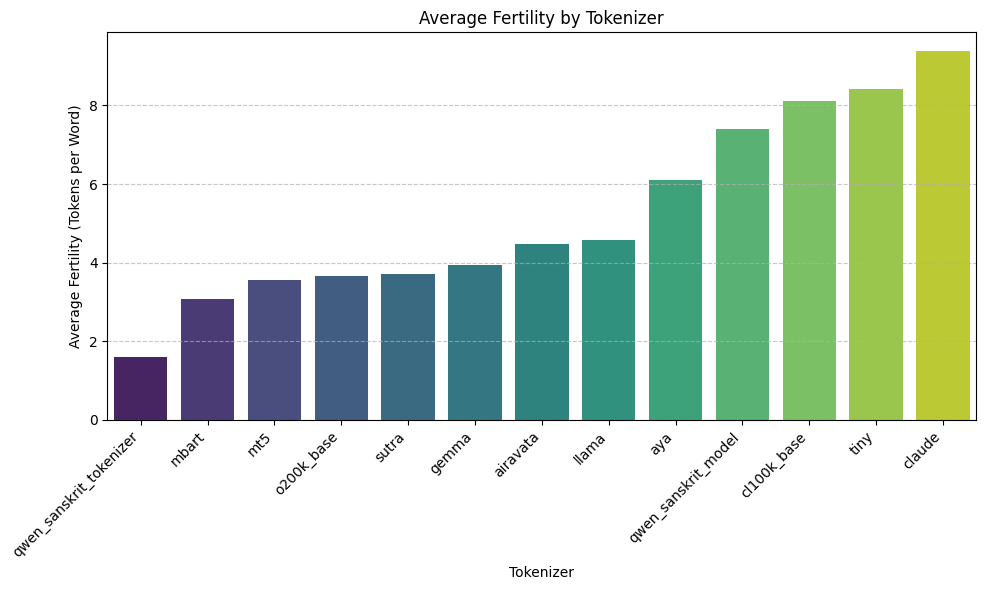

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion

# Vedic Corpus

In [1]:
!pip install datasets

README.md:   0%|          | 0.00/547 [00:00<?, ?B/s]

data/train-00000-of-00002-61fefd9cb3342d(…):   0%|          | 0.00/14.4M [00:00<?, ?B/s]

data/train-00001-of-00002-2c3d06867eb941(…):   0%|          | 0.00/14.4M [00:00<?, ?B/s]

data/test-00000-of-00001-89162c07a955ac3(…):   0%|          | 0.00/3.21M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/536641 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/59627 [00:00<?, ? examples/s]

In [16]:
from datasets import load_dataset
vedic = load_dataset("shunyasea/vedic-sanskrit")

In [17]:
print(vedic)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 536641
    })
    test: Dataset({
        features: ['text'],
        num_rows: 59627
    })
})


In [18]:
vedic = vedic["test"]["text"]

In [19]:
vedic[:5]

['वित्रेसुः सर्वभूतानि कषयं पराप्तं च मेनिरे',
 'परिष्ठिता अत्र्णद बद्बधानाः सीरा इन्द्रः सरवितवे पर्थिव्या|',
 'सयावानं धनेधने वाजयन्तम अवा रथम|',
 'त्वं च सङ्कर्षणो देवस्त्वं कर्ता त्वं सनातनः ।',
 'जितेन्द्रियश च वसुधां पराप्स्यसीति च माब्रवीत']

In [20]:
len(vedic)

59627

In [72]:
vedic = clean_text(vedic)

In [90]:
corpus_statistics(vedic)

Number of verses: 59627
Number of lines: 15549
Total characters (excluding spaces): 2085043
Total words: 345430


Average words per verse: 5.79
Average characters per verse: 34.97
Average words per line: 22.22
Average characters per line: 134.09


In [75]:
tokenizer_names = []

tokenizers = [

    ("claude", claude),
    ("tiny", tiny),
    ("sutra", sutra),
    ("qwen_sanskrit_model", qwen_sanskrit_model),
    ("qwen_sanskrit_tokenizer", qwen_sanskrit_tokenizer),
    ("mt5", mt5),
    ("mbart", mbart),
    ("airavata" , airavata), # needs login
    ("llama", llama), # needs login # access granted
    ("aya", aya), # needs login
    ("gemma", gemma), # needs login
    ("cl100k_base", gpt_enc),
    ("o200k_base", o200k_enc),


]

for tok, name in tokenizers:
  temp_df = tokenize(vedic, name, tok)
  tokenizer_names.append(temp_df)

df = pd.concat(tokenizer_names, ignore_index = True)

In [91]:
summary = (
    df
    .groupby("tokenizer")
    .agg({
        "num_words": "mean",
        "num_tokens": "mean",
        "fertility": "mean",
        "tokens_per_char": "mean",
        "chars_per_token": "mean"
    })
    .sort_values("fertility", ascending=True)
)
summary_round = round(summary, 1)
summary_round

,num_words,num_tokens,fertility,tokens_per_char,chars_per_token
tokenizer,,,,,
qwen_sanskrit_tokenizer,6.0,10.7,1.9,0.3,3.6
mbart,6.0,19.0,3.5,0.6,1.9
mt5,6.0,20.5,3.7,0.6,1.8
o200k_base,6.0,21.1,3.8,0.6,1.7
sutra,6.0,21.9,4.0,0.6,1.6
gemma,6.0,23.1,4.2,0.7,1.6
airavata,6.0,25.5,4.6,0.7,1.4
llama,6.0,25.9,4.7,0.7,1.4
aya,6.0,33.3,6.1,0.9,1.1


/tmp/ipykernel_543/3856549932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


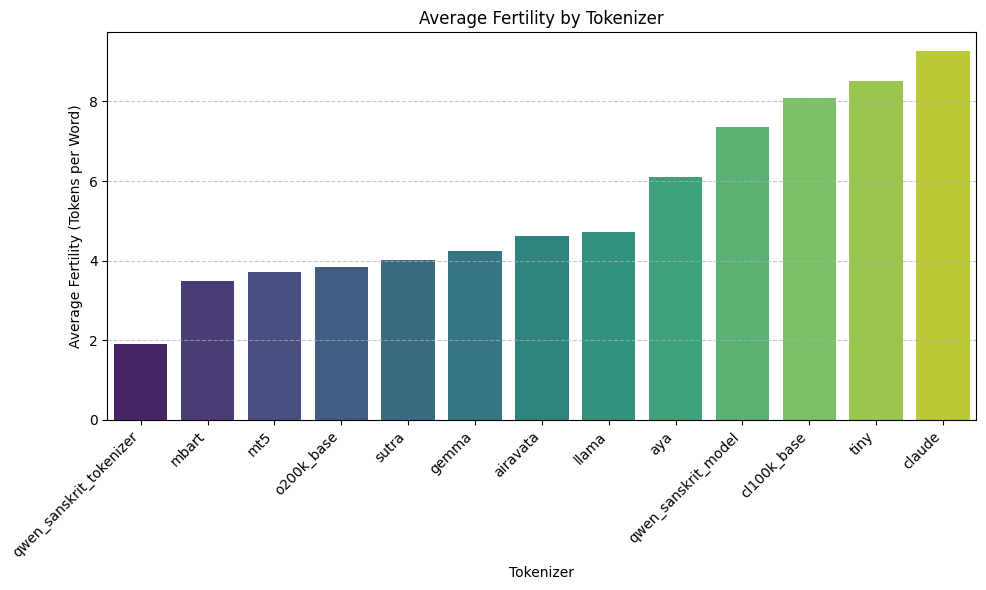

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average fertility per tokenizer
fertility_summary = (
    df.groupby('tokenizer')['fertility']
      .mean()
      .reset_index()
      .sort_values('fertility', ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='tokenizer',
    y='fertility',
    data=fertility_summary,
    palette='viridis'
)

plt.title('Average Fertility by Tokenizer')
plt.xlabel('Tokenizer')
plt.ylabel('Average Fertility (Tokens per Word)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Fine Tuned model Qwen 7B

In [52]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Load model and tokenizer
model_name = "diabolic6045/Sanskrit-Qwen2.5-7B-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True
)

# Text generation function
def generate_sanskrit_text(prompt, max_length=256, temperature=0.3):
    """
    Generate Sanskrit text from a given prompt

    Args:
        prompt (str): Sanskrit text prompt
        max_length (int): Maximum length of generated text
        temperature (float): Sampling temperature (0.1-1.0)

    Returns:
        str: Generated Sanskrit text
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_length,
            temperature=temperature,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return generated_text[len(prompt):].strip()

# Example usage
prompt = "नमस्ते संस्कृत भाषा ।"
generated = generate_sanskrit_text(prompt, max_length=30)
print(f"Prompt: {prompt}")
print(f"Generated: {generated}")


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 